<a href="https://colab.research.google.com/github/joyy-atschool/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Joy Naa Ayi-Kooley Addy  
**Student ID:** 89342028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

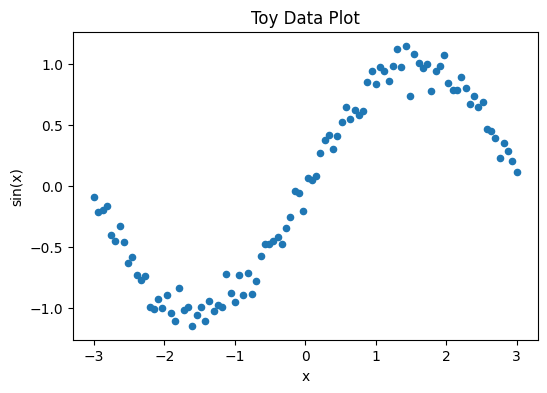

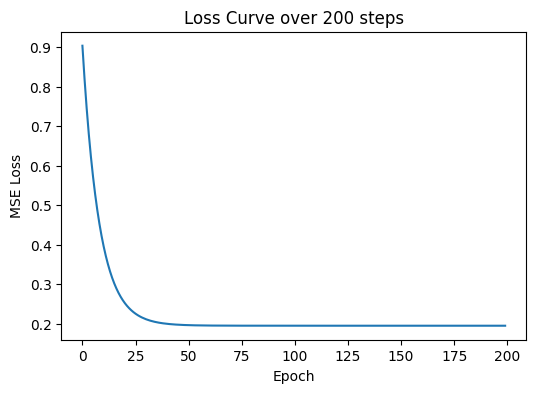

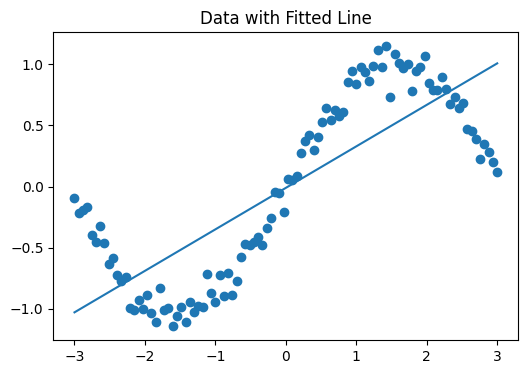

In [8]:
# TODO: Generate the toy data
#  x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)


np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)


#   Plot it.
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=20)
plt.title("Toy Data Plot")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.show()


# TODO: Initialise w and b to small random values.

w = np.random.randn()*0.1
b = np.random.randn()*0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#
lr = 0.01
epochs = 200
losses=[]

for epoch in range(epochs):
  y_hat = w * x + b
#
  loss  = np.mean((y_hat - y) ** 2)
  losses.append(loss)                            # MSE
#
  dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#
  db    = np.mean(2 * (y_hat - y))                # dLoss/db
#
  w    -= lr * dw
#
  b    -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss Curve over 200 steps")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()
#             (b) the data with the fitted line on top.

plt.figure(figsize=(6,4))
plt.scatter(x,y,label="Data")
# I did not use y_hat, because its input values may change after training
plt.plot(x,w*x+b,label = "Neuron")
plt.title("Data with Fitted Line")
plt.show()





**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match the code?*

*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*


> **Answer:**

1. The derivation matches the code.

2. There are obvious signs of underfitting. This is because the single neuron is too simple to capture the complex relationship between the input and output which we have. A single neuron would never fit a sine wave because it produces a linear model with a function of y = mx +c. A sine wave is non-linear and complex, therefore, the single neuron would never be able to fit it. The loss stops improving because the model lacks the ability to properly analyse the true function.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

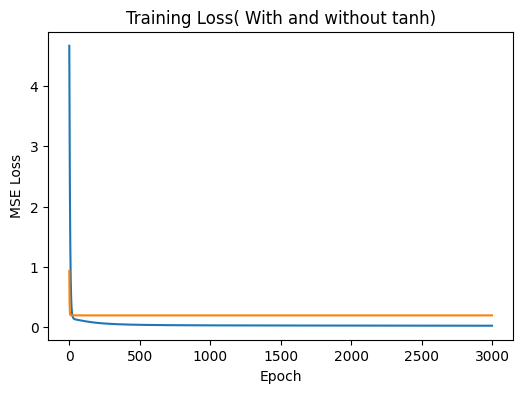

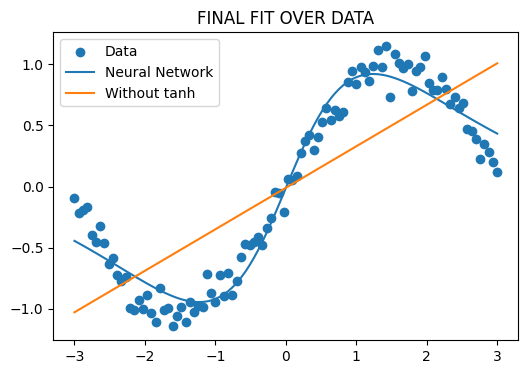

In [27]:
# TODO: Initialise parameters

x =  x.reshape(-1,1)
y = y.reshape(-1,1)

#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
W1 = np.random.randn(1,8)*0.5
b1 = np.zeros(8)

# the biases are initialised to zero in order to avoid symmetry issues. However, they can be done normally.
W2 = np.random.randn(8,1)*0.5
b2 = np.zeros(1)

#   Small random values (e.g. np.random.randn(...) * 0.5)


lr = 0.01
epochs = 3000
losses=[]


# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

for epoch in range(epochs):
  z1 = x @ W1 + b1
  #h  = np.tanh(z1)
  h = z1
  y_hat = h @ W2 + b2
  loss  = np.mean((y_hat - y) ** 2)
  losses.append(loss)


  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  #dz1 = dh * (1 - np.tanh(z1) ** 2)
  dz1 = dh
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  W1   -= lr * dW1
  b1   -= lr * db1
  W2   -= lr * dW2
  b2   -= lr * db2

#losses_tanh = losses.copy()
#W1_tanh = W1.copy()
#W2_tanh = W2.copy()


losses_linear = losses.copy()
#Final Fit loss

# TODO: Plot the loss curve AND the final fit over the data.

#Loss Plot
plt.figure(figsize=(6,4))
plt.plot(losses_tanh, label = "With tanh")
plt.plot(losses_linear, label = "Without tanh")
plt.title("Training Loss( With and without tanh)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()


#Final Fit
#y_pred = np.tanh(x @ W1+b1) @ W2 +b2

y_pred_linear = (x @ W1+b1) @ W2 +b2


plt.figure(figsize=(6,4))
plt.scatter(x,y,label = "Data")
plt.plot(x, y_pred,label= "Neural Network")
plt.plot(x,y_pred_linear,label = "Without tanh")
plt.title("FINAL FIT OVER DATA")
plt.legend()
plt.show()

#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?


**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**

1. A stack of linear layers still collapses into one linear layer simply because groups of linear transformations are still linear.
A linear layer is

y = Wx + b

Layer 1 => y1 = W1(x) +b1

Layer 2 => y2 =W2(y1) +b2

Layer 2 => y2 =(W2(W1)(x) + b1) + b2

y2 = W2(W1)(x) + W2(b1) + b2

This y2 is another linear layer because (W1)(W2) is a matrix still and  ((W2)(b1) + b2) still forms a bias we see in the original linear equations.

Therefore y2 = Wx + b. This shows that adding more linear layers with no activation still leads to another linear layer which cannot learn complex patterns in non-linearity.

2. The hidden layer's 8 neurons were in charge of different features each, which would come together to fit the curve effectively.  
With the help of the tanh which adds the non-linearity, the 8 neurons would produce different shaped curves when plotting columns of h against x. Therfore, the 8 neurons help the model to learn the different parts of the curve to be able to fit complex patterns.

3. Backpropagation is when gradients of the loss function are automatically calculated, with respect to the parameters in the model, and then the gradients are used to update the weights when we switch to training.




### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

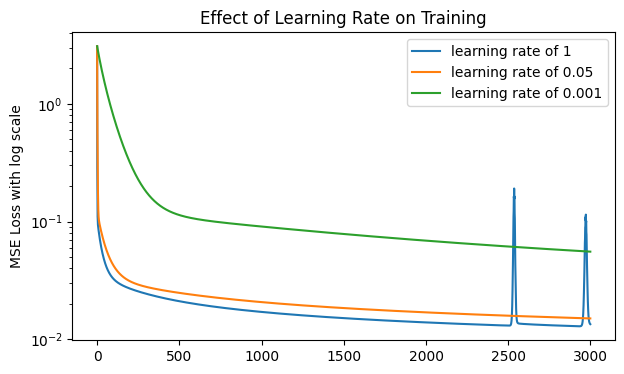

In [31]:

# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.


def train_toy(lr, steps=3000):

  np.random.seed(42)


  W1 = np.random.randn(1,8)*0.5
  b1 = np.zeros(8)

  W2 = np.random.randn(8,1)*0.5
  b2 = np.zeros(1)


  losses = []


  for step in range(steps):
    z1 = x @ W1 + b1
    h  = np.tanh(z1)

    y_hat = h @ W2 + b2
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)


    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W1   -= lr * dW1
    b1   -= lr * db1
    W2   -= lr * dW2
    b2   -= lr * db2
  return losses




# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

loss_1 = train_toy(lr=0.1,steps = 3000)
loss_2 = train_toy(lr=0.05,steps=3000)
loss_3 = train_toy(lr = 0.001,steps=3000)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.


plt.figure(figsize=(7,4))

plt.plot(loss_1,label = "learning rate of 1")
plt.plot(loss_2,label = "learning rate of 0.05")
plt.plot(loss_3,label = "learning rate of 0.001")

plt.yscale("log")
plt.ylabel("MSE Loss with log scale")
plt.title("Effect of Learning Rate on Training")


plt.legend()
plt.show()




**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:**

1. The learning rate curve for when lr=1 starts normally then oscillate towards the end.

The learning rate curve for when lr=0.05 decreases quickly, and provides the best convergence.

The learning rate curve for when lr=0.001 decreases slowly.

A too-large learning rate makes the loss explode because the model repeatedly jumps over the optimal value. The step size used to learn increases, and a step size which is too large prevents the gradient descent from settling near the minimum, cause the oscillations we see on the graph when lr=1.0.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [10]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)


obesity_encoded = obesity.copy()

binary_cols = [
    'family_history_with_overweight',
    'FAVC',
    'SMOKE',
    'SCC'
]

for col in binary_cols:
    obesity_encoded[col] = obesity_encoded[col].map({'yes': 1, 'no': 0})


obesity_encoded['CAEC'] = obesity_encoded['CAEC'].map({
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
})

obesity_encoded['CALC'] = obesity_encoded['CALC'].map({
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
})

#One-Hot for nominal
obesity_encoded = pd.get_dummies(
    obesity_encoded,
    columns=['Gender', 'MTRANS'],
    drop_first=True
)

# TODO: Encode the target `NObeyesdad` into integer class labels
#
from sklearn.preprocessing import LabelEncoder

l = LabelEncoder()

obesity_encoded['NObeyesdad'] = l.fit_transform(obesity_encoded['NObeyesdad'])


# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity_encoded.drop('NObeyesdad', axis=1)
y = obesity_encoded['NObeyesdad']

from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE)

numeric_cols = [
    'Age',
    'Height',
    'Weight',
    'FCVC',
    'NCP',
    'CH2O',
    'FAF',
    'TUE'
]


# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

s =  StandardScaler()
X_train[numeric_cols] = s.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = s.transform(X_val[numeric_cols])
X_test[numeric_cols] = s.transform(X_test[numeric_cols])

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

X_train = torch.tensor(X_train.values.astype(np.float32), dtype=torch.float32)
X_val = torch.tensor(X_val.values.astype(np.float32),dtype=torch.float32)
X_test = torch.tensor(X_test.values.astype(np.float32),dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val = torch.tensor(y_val.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

train_dataset =  TensorDataset(X_train, y_train)
val_dataset =  TensorDataset(X_val, y_val)
test_dataset =  TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset,batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=32, shuffle=False)






**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:**

1. CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch because it uses LogSoftmax and another loss procedure into a single function. The model then outputs a logit which the integer labels classify. If one-hot encoding were to be used, we would have to store the entire vector each time as compared to the indices of the correct class.

2. In random forest, data is split based on some specified feature values. Due to this, feature scaling has no effect on random trees.But for Neural networks, gradient descent is used to update weights during propagation, and this depends highly on features. Therefore, feature scaling is needed to prevent larger values from causing disproportional updates. In Section1, we see this in the formula dW1 = Xt(dz1) , where the weight gradients are directly proportional to the input values.

3. On DataLoader, shuffle=True allows for the random changing of the training samples for each batch/epoch. This would prevent any form of overfitting during training and also allow for variety in each epoch. Eventually, there would be fairness in the gradient descents leading to the model better fitting real world or unusual data.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [11]:
import torch.nn as nn
input_dim = X_train.shape[1]
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

class FeedForwardNet(nn.Module):
  def __init__(self,input_dim, hidden_sizes=(64, 32), n_classes=7,dropout=0.0):
    super().__init__()
#Loop is now added to be able to handle different hidden sizes for the experiment
    layers = []

    in_features = input_dim

    for hidden in hidden_sizes:
      layers.append(nn.Linear(in_features,hidden))
      layers.append(nn.ReLU())
      in_features = hidden

      if dropout > 0:
        layers.append(nn.Dropout(dropout))


    layers.append(nn.Linear(in_features,n_classes))

    self.network = nn.Sequential(*layers)



  def forward(self, x):

     return self.network(x)

#         ...

# TODO: Instantiate, move to DEVICE, print the model.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FeedForwardNet(input_dim).to(DEVICE)
print(model)
# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)

total_trainparams = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", total_trainparams)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
print("First Layer:", input_dim*64+64)

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable parameters: 3591
First Layer: 1280


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**
1.




2. ReLU was used instead of tanh because it keeps a constant gradient for positive inputs. For tanh, it could produce smaller gradients and introduce the vanishing gradient problem which we would like to avoid. The network would then be able to learn faster and more efficiently.

3. If we remove the ReLU, there would be no non-linearity which would lead to a linear model. The ReLU acts as an activation function helping the model to fit complex relationships. I proved earlier in part 1.2 that a group of linear layers is still linear. Therefore, removing ReLU would prevent the model from learning complex relationships(non-linear).

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

In [12]:


def run_experiment(hidden_sizes = (64,32),lr = 1e-3,batch_size=32,epochs=50,dropout=0.0):

# TODO:
  model = FeedForwardNet(input_dim, hidden_sizes=hidden_sizes,dropout=dropout).to(DEVICE)
  criterion = nn.CrossEntropyLoss()
#

  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
# or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
  epochs = 50
  train_losses = []
  val_losses = []

  train_accurs = []
  val_accurs = []

  bestValacc = 0.0

  for epoch in range(epochs):
    model.train()
    total_loss=0
    correct =0
    total =0

    for xb,yb in train_loader:
      optimizer.zero_grad()

      logits = model(xb.to(DEVICE))
      loss = criterion(logits, yb.to(DEVICE))
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
      preds = torch.argmax(logits, dim=1)
      correct += (preds == yb).sum().item()
      total += yb.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total



    model.eval()

    val_loss = 0
    correct = 0
    total = 0


    with torch.no_grad():
      for xb,yb in val_loader:
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        val_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == yb.to(DEVICE)).sum().item()
        total += yb.to(DEVICE).size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accurs.append(train_acc)
    val_accurs.append(val_acc)


# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

    if val_acc>bestValacc:
      bestValacc = val_acc
      torch.save(model.state_dict(), "ffn_best.pt")

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}")

  history = {"train_loss": train_losses,
             "val_loss":val_losses,
             "train_acc": train_accurs,
             "val_acc":val_accurs}
  return history

torch.manual_seed(42)
history = run_experiment()


Epoch 1: Train Acc=0.158, Val Acc=0.185
Epoch 2: Train Acc=0.270, Val Acc=0.321
Epoch 3: Train Acc=0.370, Val Acc=0.379
Epoch 4: Train Acc=0.447, Val Acc=0.474
Epoch 5: Train Acc=0.534, Val Acc=0.537
Epoch 6: Train Acc=0.570, Val Acc=0.566
Epoch 7: Train Acc=0.626, Val Acc=0.610
Epoch 8: Train Acc=0.643, Val Acc=0.671
Epoch 9: Train Acc=0.694, Val Acc=0.667
Epoch 10: Train Acc=0.703, Val Acc=0.711
Epoch 11: Train Acc=0.731, Val Acc=0.752
Epoch 12: Train Acc=0.806, Val Acc=0.757
Epoch 13: Train Acc=0.817, Val Acc=0.801
Epoch 14: Train Acc=0.834, Val Acc=0.796
Epoch 15: Train Acc=0.834, Val Acc=0.829
Epoch 16: Train Acc=0.858, Val Acc=0.837
Epoch 17: Train Acc=0.872, Val Acc=0.855
Epoch 18: Train Acc=0.874, Val Acc=0.855
Epoch 19: Train Acc=0.886, Val Acc=0.863
Epoch 20: Train Acc=0.908, Val Acc=0.866
Epoch 21: Train Acc=0.899, Val Acc=0.878
Epoch 22: Train Acc=0.923, Val Acc=0.880
Epoch 23: Train Acc=0.908, Val Acc=0.889
Epoch 24: Train Acc=0.934, Val Acc=0.885
Epoch 25: Train Acc=0.932

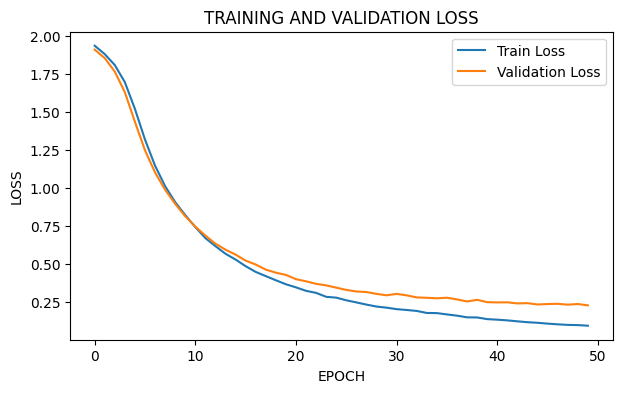

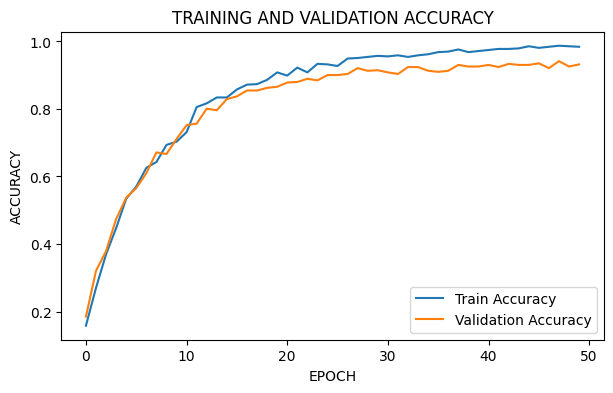

In [13]:
## TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

plt.figure(figsize=(7,4))

plt.plot(history["train_loss"],label= "Train Loss")
plt.plot(history["val_loss"],label = "Validation Loss")
plt.xlabel("EPOCH")
plt.ylabel("LOSS")
plt.title("TRAINING AND VALIDATION LOSS")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))

plt.plot(history["train_acc"],label= "Train Accuracy")
plt.plot(history["val_acc"],label = "Validation Accuracy")
plt.xlabel("EPOCH")
plt.ylabel("ACCURACY")
plt.title("TRAINING AND VALIDATION ACCURACY")
plt.legend()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:**

1.  In the NumPy implementation, we see the forward pass when we calculate the predictions and intermediate values.

z1 = x @ W1 + b1
h  = np.tanh(z1)
y_hat = h @ W2 + b2
loss  = np.mean((y_hat - y) ** 2)

For PyTorch, it corresponds to:
logits = model(xb.to(DEVICE))
loss = criterion(logits, yb.to(DEVICE))

In Numpy, the manual calculations corresponds to:

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)

These same calculations are expressed in PyTorch through the loss.backward() call.

In NumPy the parameter update is done manually with:

    W1   -= lr * dW1   
    b1   -= lr * db1
    W2   -= lr * dW2
    b2   -= lr * db2


In PyTorch it is implemented with just optimizer.step().


2. The model overfits slightly, but is well-fitted overall. From the training results , at Epoch 50:
Training accuracy = 98.4%
Validation accuracy = 93.2%

The training accuracy surpasses that of the validation which means the model has fitted the training data better than the unseen ones. The  validation however is still high meaning the model generalizes well and does not overfit that much.


3. We call optimizer.zero_grad() for every batch because for PyTorch, it aggregates the gradients by default and without restarting this process and clearing previous gradients, they would be added to the gradients of the next batch.
Therefore, the current weights would be now updated with an accumulation of gradients. This would then lead to incorrect updates leading to an inefficient training of the model

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [14]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).

print("EXPERIMENT A")
print("Tiny")
torch.manual_seed(42)
tiny = run_experiment(hidden_sizes = (8,))

print(" Default")
torch.manual_seed(42)
default = run_experiment(hidden_sizes=(64,32))
print("Large")
torch.manual_seed(42)
large = run_experiment(hidden_sizes=(256,128,64))
print(" ")

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
print("EXPERIMENT B")
print("Tiny")
torch.manual_seed(42)
lr_tiny = run_experiment(lr=1e-4)

print(" Default")
torch.manual_seed(42)
lr_default = run_experiment(lr=1e-3)
print("Large")
torch.manual_seed(42)
lr_large = run_experiment(lr=1e-1)
print(" ")
# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
print("EXPERIMENT C")

print('Without Dropout')
torch.manual_seed(42)

without_dropout =  run_experiment(hidden_sizes=(256,128,64),dropout=0.0)


print("With Dropout")
torch.manual_seed(42)

with_dropout =  run_experiment(hidden_sizes=(256,128,64),dropout=0.3)









EXPERIMENT A
Tiny
Epoch 1: Train Acc=0.136, Val Acc=0.141
Epoch 2: Train Acc=0.155, Val Acc=0.141
Epoch 3: Train Acc=0.174, Val Acc=0.164
Epoch 4: Train Acc=0.199, Val Acc=0.180
Epoch 5: Train Acc=0.226, Val Acc=0.186
Epoch 6: Train Acc=0.235, Val Acc=0.216
Epoch 7: Train Acc=0.303, Val Acc=0.267
Epoch 8: Train Acc=0.336, Val Acc=0.299
Epoch 9: Train Acc=0.365, Val Acc=0.318
Epoch 10: Train Acc=0.370, Val Acc=0.338
Epoch 11: Train Acc=0.367, Val Acc=0.348
Epoch 12: Train Acc=0.370, Val Acc=0.348
Epoch 13: Train Acc=0.370, Val Acc=0.360
Epoch 14: Train Acc=0.378, Val Acc=0.392
Epoch 15: Train Acc=0.400, Val Acc=0.428
Epoch 16: Train Acc=0.458, Val Acc=0.469
Epoch 17: Train Acc=0.515, Val Acc=0.517
Epoch 18: Train Acc=0.536, Val Acc=0.534
Epoch 19: Train Acc=0.556, Val Acc=0.548
Epoch 20: Train Acc=0.570, Val Acc=0.548
Epoch 21: Train Acc=0.577, Val Acc=0.543
Epoch 22: Train Acc=0.588, Val Acc=0.573
Epoch 23: Train Acc=0.591, Val Acc=0.575
Epoch 24: Train Acc=0.589, Val Acc=0.586
Epoch 2

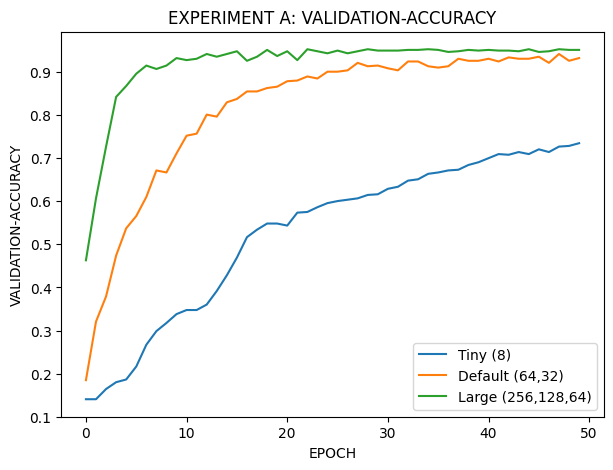

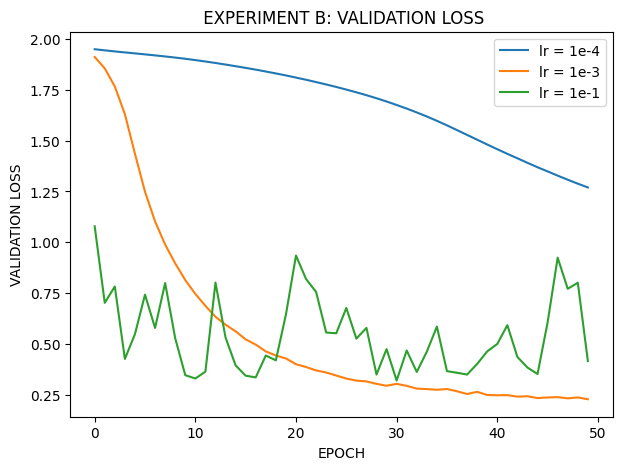

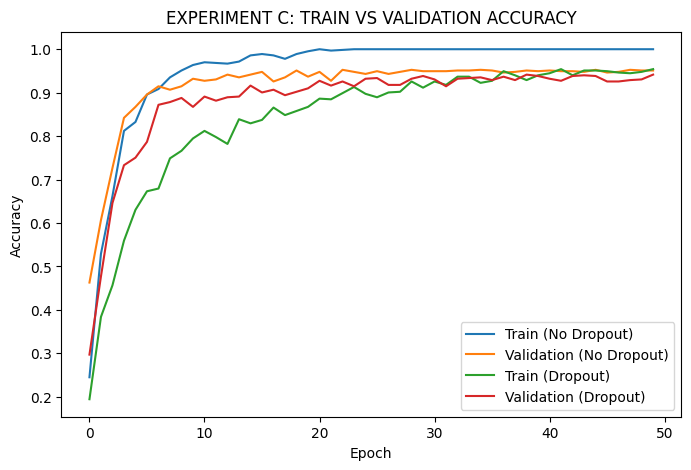

In [15]:
#   Plot the three validation-accuracy curves together.
plt.figure(figsize=(7,5))

plt.plot(tiny["val_acc"], label="Tiny (8)")
plt.plot(default["val_acc"], label="Default (64,32)")
plt.plot(large["val_acc"], label="Large (256,128,64)")
plt.xlabel("EPOCH")
plt.ylabel("VALIDATION-ACCURACY")
plt.title("EXPERIMENT A: VALIDATION-ACCURACY")
plt.legend()
plt.show()

#   Plot the three validation-loss curves together. Compare with Part 1.3.
plt.figure(figsize=(7,5))

plt.plot(lr_tiny["val_loss"], label="lr = 1e-4")
plt.plot(lr_default["val_loss"], label="lr = 1e-3")
plt.plot(lr_large["val_loss"], label="lr = 1e-1")
plt.xlabel("EPOCH")
plt.ylabel("VALIDATION LOSS")
plt.title(" EXPERIMENT B: VALIDATION LOSS")
plt.legend()
plt.show()

#   Plot train vs validation accuracy for both runs.
plt.figure(figsize=(8,5))

plt.plot(without_dropout["train_acc"], label="Train (No Dropout)")
plt.plot(without_dropout["val_acc"], label="Validation (No Dropout)")

plt.plot(with_dropout["train_acc"], label="Train (Dropout)")
plt.plot(with_dropout["val_acc"], label="Validation (Dropout)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EXPERIMENT C: TRAIN VS VALIDATION ACCURACY")
plt.legend()
plt.show()





**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:**
1. Yes, the largest network won on the validation data, it reached a 95.3% as compared to the 93.2% for the deafult and the 73.5% for the tiny network. I see some diminishing returns from the gap between the large network and the default. Overfitting also occurs in the large network where it reached 100% training accuracy while the validation accuracy remained at about 95%. This shows that there is some form of menorisation of the training data, because the accuracy for the validation data was not as good.

2. Yes, the three refimes match what was seen in the toy problem in Part 1.3. For that problem, the model with the small learning rate(0.001) has a slower learning path and reached a validation accuracy of 57% after the 50 epochs. The default learning rate


3. When we introduced the droppout, the train-vs-validation gap was reduced. With the no dropout model, the training accuracy was 100% and the validationw as 95%, when the dropout was introduced the 2 values came closer with the training accuracy at 95.4% and the validation at 94.2%. This also indicates that the dropout helped to reduce overfitting during training also.

Dropout achieves this by dropping or disabling a set amount of neurons at each step of the training process. This is too prevent the network from relying too heavily on a specific neuron and allows the model to fit well on unfamiliar data.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Epoch 1: Train Acc=0.245, Val Acc=0.463
Epoch 2: Train Acc=0.529, Val Acc=0.607
Epoch 3: Train Acc=0.662, Val Acc=0.727
Epoch 4: Train Acc=0.812, Val Acc=0.842
Epoch 5: Train Acc=0.833, Val Acc=0.867
Epoch 6: Train Acc=0.896, Val Acc=0.896
Epoch 7: Train Acc=0.908, Val Acc=0.915
Epoch 8: Train Acc=0.935, Val Acc=0.907
Epoch 9: Train Acc=0.951, Val Acc=0.915
Epoch 10: Train Acc=0.964, Val Acc=0.932
Epoch 11: Train Acc=0.970, Val Acc=0.927
Epoch 12: Train Acc=0.968, Val Acc=0.930
Epoch 13: Train Acc=0.967, Val Acc=0.942
Epoch 14: Train Acc=0.972, Val Acc=0.935
Epoch 15: Train Acc=0.986, Val Acc=0.942
Epoch 16: Train Acc=0.989, Val Acc=0.948
Epoch 17: Train Acc=0.986, Val Acc=0.926
Epoch 18: Train Acc=0.978, Val Acc=0.935
Epoch 19: Train Acc=0.989, Val Acc=0.951
Epoch 20: Train Acc=0.995, Val Acc=0.937
Epoch 21: Train Acc=1.000, Val Acc=0.948
Epoch 22: Train Acc=0.997, Val Acc=0.927
Epoch 23: Train Acc=0.998, Val Acc=0.953
Epoch 24: Train Acc=1.000, Val Acc=0.948
Epoch 25: Train Acc=1.000

,Model,Test Accuracy,Macro F1,Training Time,Parameters/Trees
0,Random Forest,0.995272,0.995457,0.4 s,100 trees
1,FeedForward Neural Network,0.937278,0.935048,1.971246,46727


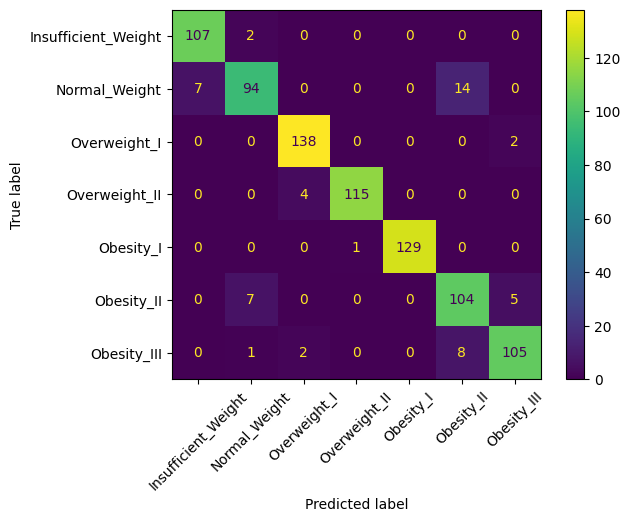

In [17]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import time

# TODO: Load your best configuration's weights; model.eval().

start =  time.time()
torch.manual_seed(42)

run_experiment(
    hidden_sizes=(256,128,64),
    dropout=0.0
)
end = time.time()
best_model = FeedForwardNet(
    input_dim,
    hidden_sizes=(256,128,64),
    dropout=0.0
).to(DEVICE)


best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model.eval()

# TODO: Report test ACCURACY and MACRO-F1
#

predics = []
labells = []

with torch.no_grad():
    for xb, yb in test_loader:

        xb = xb.to(DEVICE)

        logits = best_model(xb)

        preds = torch.argmax(logits, dim=1)

        predics.extend(preds.cpu().numpy())
        labells.extend(yb.numpy())


test_acc = accuracy_score(labells, predics)
test_f1 = f1_score(labells, predics, average="macro")

print("Test Accuracy:", test_acc)
print("Macro F1:", test_f1)

print(classification_report(labells, predics))

# TODO: Confusion matrix for the test set with the 7 class names
#
class_names = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_I",
    "Overweight_II",
    "Obesity_I",
    "Obesity_II",
    "Obesity_III"
]

cm = confusion_matrix(labells, predics)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

comparison = pd.DataFrame({
    "Model":[
        "Random Forest",
        "FeedForward Neural Network"
    ],
    "Test Accuracy":[
        0.9952718676122931,
        test_acc
    ],
    "Macro F1":[
        0.9954565354928734,
        test_f1
    ],
    "Training Time":[
        "0.4 s",
        end-start
    ],
    "Parameters/Trees":[
        "100 trees",
        sum(p.numel() for p in best_model.parameters())
    ]
})

comparison



**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:**


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.